# Notebook for practical exercises | Week #4 Lesson #2

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Convolutional Neural Networks for Segmentation*.

After this session, you will know how to evaluate and improve the performance of a classifier for a real-world segmentation problem:
- Train CNN models for pixel-level segmentation.
- Benchmark several model architectures (UNet, FCN, DeepLabV3).
- Compare segmentation results using Dice and IoU scores.

## Dataset

We will use the [The Brain Resection Multimodal Imaging Database](https://www.cancerimagingarchive.net/collection/remind/) [1]. The Brain Resection Multimodal Imaging Database (ReMIND) contains pre- and intra-operative brain MRI collected on 114 consecutive patients who were surgically treated with image-guided tumor resection between 2018 and 2022.

[1] Juvekar, P., Dorent, R., Kögl, F., Torio, E., Barr, C., Rigolo, L., Galvin, C., Jowkar, N., Kazi, A., Haouchine, N., Cheema, H., Navab, N., Pieper, S., Wells, W. M., Bi, W. L., Golby, A., Frisken, S., & Kapur, T. (2023). The Brain Resection Multimodal Imaging Database (ReMIND) (Version 1) [dataset]. The Cancer Imaging Archive. [https://doi.org/10.7937/3RAG-D070](https://doi.org/10.7937/3RAG-D070)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from glob import glob
import warnings

warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import tv_tensors
from sklearn.model_selection import train_test_split

!pip install SimpleITK
sys.path.append('../..')
from utils.sitk_utils import load_dicom_series_to_3d_image, convert_np_to_sitk, reconstruct_mask_in_image_space
from PIL import Image
import SimpleITK as sitk
sitk.ProcessObject_SetGlobalWarningDisplay(False)

### Download

If needed, run the following cells to download and unzip the dataset. If you already have the dataset downloaded, comment the two lines.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [3]:
DATA_PATH = '../..'

!curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
!unzip {DATA_PATH}/data.zip -d {DATA_PATH}

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-055.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-055.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-032.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-032.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-026.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-026.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-146.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-146.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-152.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-152.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-185.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-185.dcm  
  inflating: ../../data/ReMIND/sub-097/anat/T1w/1-191.dcm  
  inflating: ../../__MACOSX/data/ReMIND/sub-097/anat/T1w/._1-191.dcm  
  inf

### Dataset Class

Similarly to what we have done for classification and detection, we need to create a `Dataset` class for the segmentation task.
Observe the following cell and compare with the classes we created in lesson #1.

<div class="alert alert-block alert-info">
<b>Q1.</b> Load the metadata csv file of the ReMIND dataset and observe the data. 
</div>

In [5]:
# Load and observe available data
clinical_df = pd.read_csv(f'{DATA_PATH}/data/ReMIND/ReMIND_metadata.csv')
clinical_df.head() # Print the 5 fist rows of the dataframe

,Case Number,Age,Sex,Race,Ethnicity,Laterality,Previous Craniotomy,WHO Grade,Histopathology
0,1,41,Male,White,Not Hispanic,Right,No,3,Astrocytoma
1,2,22,Female,White,Not Hispanic,Right,No,2,Astrocytoma
2,3,30,Male,Asian,Not Hispanic,Left,No,2,Oligodendroglioma
3,4,23,Male,White,Hispanic,Left,No,1,Dysembryoplastic neuroepithelial tumor
4,5,27,Male,White,Not Hispanic,Right,No,Not assigned,Non-tumor epileptogenic brain parenchyma and g...


In [6]:
class SegmentationDataset(Dataset):
    def __init__(self, clinical_df, data_dir, transf=None, size=512):
        self.data_dir = data_dir

        self.transf_image = transforms.Compose([
                          transforms.ToPILImage(),
                          transforms.Resize((size, size)),
                          transforms.ToTensor(),
                          lambda x: x / (x.max() + 1e-7),
                          lambda x: x.repeat(3, 1, 1),

                          ])
        self.transf_mask = transforms.Compose([
                          transforms.ToPILImage(),
                          transforms.Resize((size, size), interpolation=transforms.InterpolationMode.NEAREST),
                          transforms.ToTensor()])

        self.size = size
        self.slices = []

        # Loop over patients and store individual slices
        for patient, tumor in zip(clinical_df['Case Number'], clinical_df['WHO Grade']):
            idx = str(patient).zfill(3)
            img_dirname = glob(f'{data_dir}/data/ReMIND/sub-{idx}/anat/T1w')
            seg_fname = glob(f'{data_dir}/data/ReMIND/sub-{idx}/seg/ReMIND-{idx}-preop-SEG-tumor-*.nrrd')

            if len(img_dirname) == 0 or len(seg_fname) == 0:
                continue

            # Load 3D volumes
            image_sitk = load_dicom_series_to_3d_image(img_dirname[0])
            image_array = sitk.GetArrayFromImage(image_sitk)  # shape: (D, H, W)

            reader = sitk.ImageFileReader()
            reader.SetImageIO("NrrdImageIO")
            reader.SetFileName(seg_fname[0])
            mask_sitk = reader.Execute()
            mask_sitk_rec = reconstruct_mask_in_image_space(mask_sitk, image_sitk)
            mask_array = sitk.GetArrayFromImage(mask_sitk_rec)  # shape: (D, H, W)

            # Store each slice as a separate entry
            for slice_idx in range(image_array.shape[0]):
              if len(np.unique(mask_array[slice_idx])) > 1:
                  self.slices.append({
                      "image": image_array[slice_idx],
                      "mask": mask_array[slice_idx]
                  })

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        img = self.slices[idx]["image"]  # shape: (H, W)
        mask = self.slices[idx]["mask"]

        img = np.nan_to_num(img)

        mask = (mask > 0.5).astype(float)
        mask = np.nan_to_num(mask)

        img, mask = self.transf_image(img), self.transf_mask(mask)

        return img, mask

<div class="alert alert-block alert-info">
<b>Q2.</b> In the previous cell, we created the <code>Dataset</code> class for the segmentation task. Observe the code. <br>
    Create an instance of <code>SegmentationDataset</code> containing all ReMIND samples and print a few samples.
</div>

In [41]:
seg_dataset = SegmentationDataset(clinical_df, DATA_PATH)

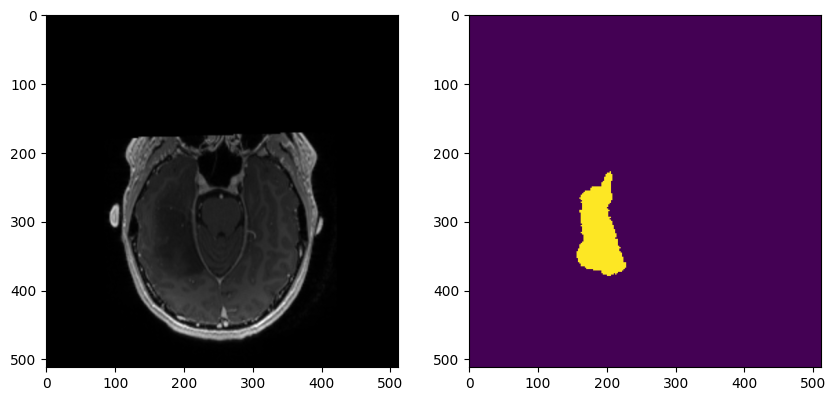

In [44]:
# Shape of the image
f, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(np.transpose(seg_dataset[360][0], (1,2,0)), 'Grays')
ax[1].imshow(np.transpose(seg_dataset[360][1], (1,2,0)))

## Tumor Segmentation

We will use CNN models for binary semantic segmentation: predicting a tumor mask for each input MRI slice.
We will:
- Load a pretrained segmentation model (e.g., FCN).
- Train on the dataset using Dice or BCE loss.
- Visualize predictions and compare to ground truth.
- Benchmark multiple models (UNet, FCN, DeepLabV3).

### Dataset split

Before, we need to split our dataset with training, validation and test sets.

<div class="alert alert-block alert-info">
<b>Q1.</b> Split the dataset using the <code>train_test_split</code> function from scikit-learn and create the three variables: <code>train_dataset</code>, <code>val_dataset</code>, <code>test_dataset</code>.
</div>

In [10]:
patient_list = clinical_df['Case Number'].unique()

patient_train, patient_test = train_test_split(
    patient_list, # List or array to split
    test_size= 0.2, # Size of the subset
    random_state=42)

patient_train, patient_val = train_test_split(
    patient_train, # List or array to split
    test_size= 0.1, # Size of the subset
    random_state=42)

train_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_train)]
test_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_test)]
val_df = clinical_df.loc[clinical_df['Case Number'].isin(patient_val)]

In the following, we will create and fine-tune a segmentation network named FCN. 

In [11]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

# Load a pretrained FCN model and modify for binary segmentation
model = fcn_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(512, 1, kernel_size=1)  # Binary class

print(model)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth
100%|██████████| 135M/135M [00:00<00:00, 174MB/s]


FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

<div class="alert alert-block alert-info">
<b>Q2.</b> In the following cell, we implemented the training loop for segmentation. Implement the corresponding validation loop.
</div>

In [12]:
def train_loop(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, masks in dataloader:
        torch.cuda.empty_cache()
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)["out"]
        loss = criterion(outputs.float(), masks.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print('Loss:', running_loss / len(dataloader))

def val_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)["out"]
        loss = criterion(outputs.float(), masks.float())

        running_loss += loss.item()

    print('Validation loss:', running_loss / len(dataloader))

In [13]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
learning_rate = 1e-4
batch_size = 8
epochs = 20

train_dataset = SegmentationDataset(train_df, DATA_PATH)
val_dataset = SegmentationDataset(val_df, DATA_PATH)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1)

model.to(device)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(model, train_dataloader, optimizer, criterion, device)
     # update the learning rate
    lr_scheduler.step()
    val_loop(model, val_dataloader, criterion, device)
print("Done!")
torch.save(model.state_dict(), 'fcn_segmentation.pth')

Epoch 1
-------------------------------
0.1606926232645357
Epoch 2
-------------------------------
0.04522691550952049
Epoch 3
-------------------------------
0.024703385207779063
Epoch 4
-------------------------------
0.01562700137484497
Epoch 5
-------------------------------
0.0121374648210972
Epoch 6
-------------------------------
0.009356598615542881
Epoch 7
-------------------------------
0.007425773673242441
Epoch 8
-------------------------------
0.006240973368367571
Epoch 9
-------------------------------
0.005570455944384046
Epoch 10
-------------------------------
0.0052351425912081735
Epoch 11
-------------------------------
0.005152064303718048
Epoch 12
-------------------------------
0.005102362092095715
Epoch 13
-------------------------------
0.005059280800690622
Epoch 14
-------------------------------
0.005156510858077924
Epoch 15
-------------------------------
0.006062508590898856
Epoch 16
-------------------------------
0.01109598253071768
Epoch 17
--------------

<div class="alert alert-block alert-info">
<b>Q3.</b> In the previous training, we used a <code>BCELoss</code> to optimize performance. But segmentation models can also be trained using other metrics, such as the DICE coefficient. In the following, we implemented the <code>DiceLoss</code> and <code>BCEDiceLoss</code>.
    Train the FCN model using these two losses, print the results on the validation set and compare.
</div>

In [67]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        """
        logits: raw output from the model (N, 1, H, W)
        targets: ground truth masks (N, 1, H, W) or (N, H, W)
        """
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2. * intersection + self.eps) / (union + self.eps)
        loss = 1 - dice
        return loss.mean()

class BCEDiceLoss(nn.Module):
    def __init__(self, weight_bce=0.5, weight_dice=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.w_bce = weight_bce
        self.w_dice = weight_dice

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets.float())
        dice_loss = self.dice(logits, targets)
        return self.w_bce * bce_loss + self.w_dice * dice_loss

In [68]:
# Load a pretrained FCN model and modify for binary segmentation
model = fcn_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(512, 1, kernel_size=1)  # Binary class

learning_rate = 1e-4
batch_size = 8
epochs = 20

train_dataset = SegmentationDataset(train_df, DATA_PATH)
val_dataset = SegmentationDataset(val_df, DATA_PATH)

# Define loss function and optimizer
criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1)

model.to(device)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(model, train_dataloader, optimizer, criterion, device)
     # update the learning rate
    lr_scheduler.step()
print("Done!")
torch.save(model.state_dict(), 'fcn_bcedice_segmentation.pth')

Epoch 1
-------------------------------
0.5055696605532257
Epoch 2
-------------------------------
0.2948623059064518
Epoch 3
-------------------------------
0.20105748448842836
Epoch 4
-------------------------------
0.15192641614487878
Epoch 5
-------------------------------
0.12416703318372185
Epoch 6
-------------------------------
0.10130131313646282
Epoch 7
-------------------------------
0.08784274606287111
Epoch 8
-------------------------------
0.07654165977865089
Epoch 9
-------------------------------
0.06876288390040029
Epoch 10
-------------------------------
0.06377465049103823
Epoch 11
-------------------------------
0.062220347654304384
Epoch 12
-------------------------------
0.06217013599558009
Epoch 13
-------------------------------
0.06160596150467977
Epoch 14
-------------------------------
0.06199954996276417
Epoch 15
-------------------------------
0.0661878663195688
Epoch 16
-------------------------------
0.072923262540343
Epoch 17
----------------------------

In [69]:
# Load a pretrained FCN model and modify for binary segmentation
model = fcn_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(512, 1, kernel_size=1)  # Binary class

learning_rate = 1e-4
batch_size = 8
epochs = 20

train_dataset = SegmentationDataset(train_df, DATA_PATH)
val_dataset = SegmentationDataset(val_df, DATA_PATH)

# Define loss function and optimizer
criterion = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1)

model.to(device)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(model, train_dataloader, optimizer, criterion, device)
     # update the learning rate
    lr_scheduler.step()
print("Done!")
torch.save(model.state_dict(), 'fcn_dice_segmentation.pth')

## Evaluation

Now, we will evaluate the model using:
* Dice Score
* Mean IoU
* Pixel-wise Precision/Recall

<div class="alert alert-block alert-info">
<b>Q4.</b> Complete the following functions to compute the DICE score and IoU. Complete the validation loop to incorporate these metrics.
</div>

In [99]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred) > threshold
    target = target > threshold
    intersection = (pred & target).float().sum((1, 2, 3))
    union = pred.float().sum((1, 2, 3)) + target.float().sum((1, 2, 3))
    dice = (2. * intersection + 1e-7) / (union + 1e-7)
    return dice.mean().item()

def compute_iou(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    """
    Computes IoU between predicted and ground truth masks.
    pred_mask, true_mask: torch tensors of shape (N, 1, H, W)
    """
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    true = (true_mask > 0.5).float()

    intersection = (pred * true).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + true.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def compute_precision_recall(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    """
    Computes pixel-level precision and recall.
    """
    pred = (torch.sigmoid(pred_mask) > threshold).float()
    true = (true_mask > 0.5).float()

    TP = (pred * true).sum(dim=(1, 2, 3))
    FP = (pred * (1 - true)).sum(dim=(1, 2, 3))
    FN = ((1 - pred) * true).sum(dim=(1, 2, 3))

    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)

    return precision.mean().item(), recall.mean().item()

def eval_loop(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_scores = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images, )["out"]
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            dice = dice_score(outputs, masks)
            dice_scores.append(dice)

    return val_loss / len(dataloader), sum(dice_scores) / len(dice_scores)

<div class="alert alert-block alert-info">
<b>Q5.</b> Run the evaluation loop with all metrics on the three models and visualize the results.
</div>

In [106]:
model = fcn_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(512, 1, kernel_size=1)  # Binary class
model.load_state_dict(torch.load('fcn_segmentation.pth'))
model.to(device)

val_dataset = SegmentationDataset(val_df, DATA_PATH)
val_dataloader = DataLoader(val_dataset, batch_size=1)

val_loss, val_dice = eval_loop(model, val_dataloader, criterion, device)
print('Validation loss:', val_loss)
print('DICE score:', val_dice)

Validation loss: 0.4822954908190317
DICE score: 0.1730673891517401


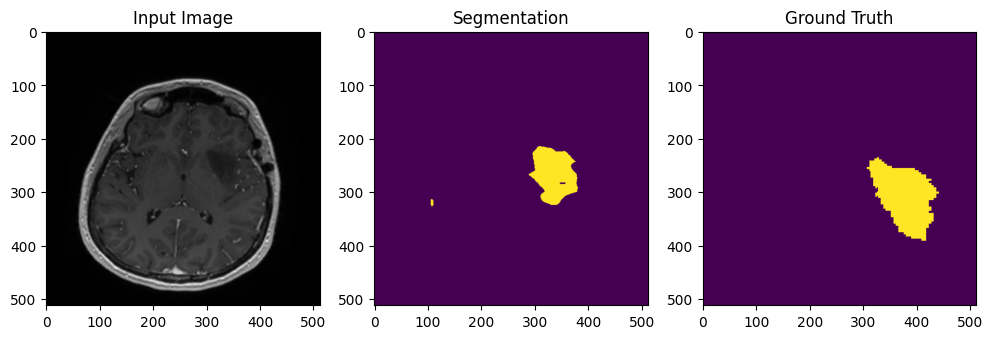

Dice score: 0.4163110852241516


In [125]:
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=True)

for images, masks in val_dataloader:
  images = images.to(device)
  masks = masks.to(device)

  outputs = model(images, )["out"]
  pred = torch.sigmoid(outputs) > 0.01

  # Visualize a few good and bad samples
  fig, ax = plt.subplots(1, 3, figsize=(12, 5))
  ax[0].imshow(images.detach().cpu().numpy()[0].transpose((1,2,0)), 'Grays')
  ax[0].set_title("Input Image")
  ax[1].imshow(pred.detach().cpu().numpy()[0][0])
  ax[1].set_title("Segmentation")
  ax[2].imshow(np.transpose(masks.detach().cpu().numpy()[0], (1,2,0)) )
  ax[2].set_title("Ground Truth")
  plt.show()

  print('Dice score:', dice_score(outputs, masks, threshold=0.01))

  break

In [126]:
model = fcn_resnet50(pretrained=True)
model.classifier[4] = torch.nn.Conv2d(512, 1, kernel_size=1)  # Binary class
model.load_state_dict(torch.load('fcn_segmentation_bce_dice.pth'))
model.to(device)

val_dataset = SegmentationDataset(val_df, DATA_PATH)
val_dataloader = DataLoader(val_dataset, batch_size=32)

val_loss, val_dice = eval_loop(model, val_dataloader, criterion, device)
print('Validation loss:', val_loss)
print('DICE score:', val_dice)

Validation loss: 0.5095020277159554
DICE score: 0.1788875744042688


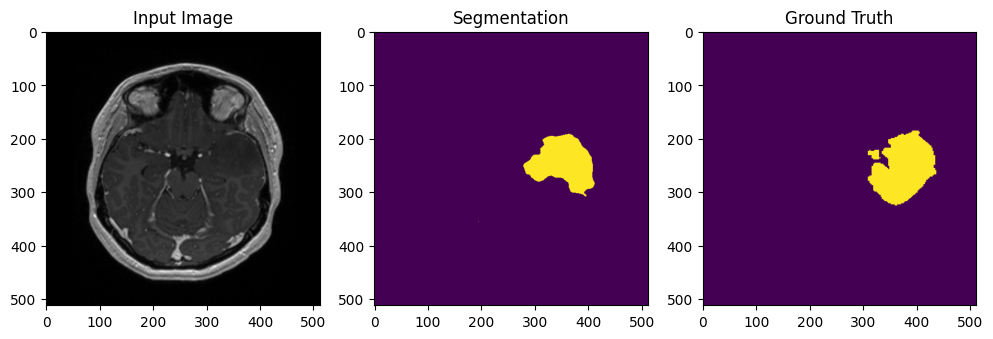

Dice score: 0.6367743015289307


In [136]:
val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=True)

for images, masks in val_dataloader:
  images = images.to(device)
  masks = masks.to(device)

  outputs = model(images, )["out"]
  pred = torch.sigmoid(outputs) > 0.01

  # Visualize a few good and bad samples
  fig, ax = plt.subplots(1, 3, figsize=(12, 5))
  ax[0].imshow(images.detach().cpu().numpy()[0].transpose((1,2,0)), 'Grays')
  ax[0].set_title("Input Image")
  ax[1].imshow(pred.detach().cpu().numpy()[0][0])
  ax[1].set_title("Segmentation")
  ax[2].imshow(np.transpose(masks.detach().cpu().numpy()[0], (1,2,0)) )
  ax[2].set_title("Ground Truth")
  plt.show()

  print('Dice score:', dice_score(outputs, masks, threshold=0.01))

  break

## Comparison with a Foundation Model: MedSAM

Unlike standard models like UNet or FCN, MedSAM is based on the Segment Anything framework and requires explicit prompts (e.g., bounding boxes or points) to identify what should be segmented.

This design makes it highly flexible and interactive — ideal for annotation, medical workflows, or semi-supervised segmentation.

In [31]:
# Install MedSAM from GitHub (e.g., https://github.com/bowang-lab/MedSAM)

!pip install -q git+https://github.com/bowang-lab/MedSAM.git
!wget -O medsam_vit_b.pth https://zenodo.org/records/10689643/files/medsam_vit_b.pth

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.7/515.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.7 MB/s eta 0:00:00
--2025-06-13 05:52:34--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [applicatio

In [137]:
from segment_anything import sam_model_registry

#%% load model and checkpoint
MedSAM_CKPT_PATH = "/content/medsam_vit_b.pth"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
medsam_model = medsam_model.to(device)
medsam_model.eval() 
# Here, we only evaluate the model, we will not re-train or fine-tune it.

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In the following cell, we provide utility functions to infer with MedSAM. 

<div class="alert alert-block alert-danger">
<b>MedSAM requires the definition of bounding boxes, serving as prompts. For simplicity, we will use the boxes from the mask. 
In practice, you would not have access to this information and would have to prompt a different bounding box for each image.</b> </div>

In [ ]:
# Visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

def get_bounding_box_from_mask(mask):
    # mask: torch.Tensor or numpy array, shape (H, W), binary
    coords = torch.nonzero(mask[0][0])
    y_min, x_min = coords.min(0).values
    y_max, x_max = coords.max(0).values
    return [x_min.item(), y_min.item(), x_max.item(), y_max.item()]

@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :] # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed, # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
        multimask_output=False,
        )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = nn.functional.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg

def eval_loop_medsam(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_scores = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            box_np = [get_bounding_box_from_mask(masks)]
            box = box_np / np.array([1024, 1024, 1024, 1024]) * 1024

            image_embedding = medsam_model.image_encoder(images) # (1, 256, 64, 64)
            medsam_seg = medsam_inference(medsam_model, image_embedding, box, 1024, 1024)
            outputs = torch.from_numpy(medsam_seg).float().unsqueeze(0).unsqueeze(0).to(device)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            dice = dice_score(outputs, masks)
            dice_scores.append(dice)

    return val_loss / len(dataloader), sum(dice_scores) / len(dice_scores)


<div class="alert alert-block alert-info">
<b>Q6.</b> Create the <code>SegmentationDataset</code> instance, with a size of 1024, as MedSAM only accept images of this size. Create a <code>DataLoader</code> and run the evaluation loop. Print the validation loss and DICE score.
</div>

In [139]:
val_dataset = SegmentationDataset(val_df, DATA_PATH, size=1024)
val_dataloader = DataLoader(val_dataset, batch_size=1)

val_loss, val_dice = eval_loop_medsam(medsam_model, val_dataloader, criterion, device)
print('Validation loss:', val_loss)
print('DICE score:', val_dice)

Validation loss: 0.8204568279044362
DICE score: 0.6297356598574919


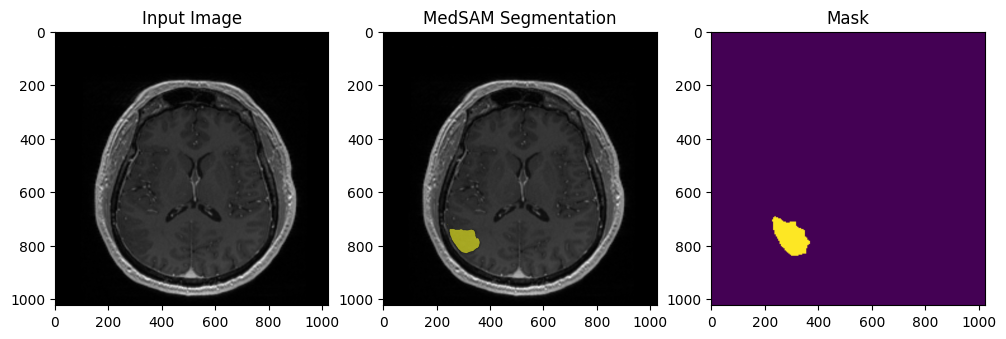

Dice score: 0.7400040030479431


In [142]:
for images, masks in val_dataloader:
  images = images.to(device)
  masks = masks.to(device)

  box_np = [get_bounding_box_from_mask(masks)]
  box = box_np / np.array([1024, 1024, 1024, 1024]) * 1024

  with torch.no_grad():
    image_embedding = medsam_model.image_encoder(images)
    medsam_seg = medsam_inference(medsam_model, image_embedding, box, 1024, 1024)

  outputs = model(images, )["out"]
  pred = torch.sigmoid(outputs) > 0.01

  fig, ax = plt.subplots(1, 3, figsize=(12, 5))
  ax[0].imshow(images.detach().cpu().numpy()[0].transpose((1,2,0)), 'Grays')
  ax[0].set_title("Input Image")
  ax[1].imshow(images.detach().cpu().numpy()[0].transpose((1,2,0)), 'Grays')
  show_mask(medsam_seg, ax[1])
  ax[1].set_title("MedSAM Segmentation")
  ax[2].imshow(masks.detach().cpu().numpy()[0][0])
  ax[2].set_title("Mask")
  plt.show()

  outputs = torch.from_numpy(medsam_seg).float().unsqueeze(0).unsqueeze(0).to(device)
  print('Dice score:', dice_score(outputs, masks))

  break


<div class="alert alert-block alert-info">
<b>Conclude.</b> Based on the computation time of fine-tuning models like FCN, the performance and ease of use, which model would you recommend? 
</div>

In this notebook, we explored multiple segmentation strategies for medical imaging, including fully supervised models like FCN and prompt-based models like MedSAM. While FCN offers full automation and decent performance with proper training, it requires significant computational resources and annotated data for fine-tuning. In contrast, MedSAM provides an efficient and flexible alternative: it enables high-quality segmentation with minimal supervision by leveraging prompt-based interaction (e.g., bounding boxes). For practical applications—especially when manual annotations are limited or real-time feedback is needed—MedSAM is a compelling choice. However, when a large, labeled dataset is available and full automation is essential, training or fine-tuning a model like FCN or UNet remains a solid, high-performance option. Choosing the best model ultimately depends on your data availability, time constraints, and desired level of control.